# Introduction to Quantitative Biology — Lecture 2
## From one gene to a network

*Luca Ciandrini — luca.ciandrini@umontpellier.fr*

In Lecture 1 the equation $dY/dt = \beta - \alpha Y$ gave one smooth curve, the same for every cell,
and at division we saw that sister cells do not receive the same number of molecules.

Today:
1. **Sections 1--3.** A short recap of three ways to describe the same gene --- the analytical
   solution, a numerical solution, a stochastic simulation --- and why the distribution over cells
   is a **Poisson**.
2. **Section 4.** The **input function**: how the production rate of a gene depends on the
   transcription factor that regulates it.
3. **Sections 5--7.** **Network motifs**: a pattern that the real *E. coli* network contains far
   more often than chance would, a gene that represses itself, and two things it is good for ---
   it responds **faster**, and its steady state is **less sensitive** to differences between cells.

**How to use it.** Before running a cell marked **🔮 Predict**, write down what you expect.

> ### Conventions, once and for all
>
> We follow the notation of Alon's book, the same as in the pre-read.
>
> - **A symbol standing for a molecule means its concentration.** $X$ is the concentration of the
>   transcription factor $X$, $Y$ the concentration of the protein a gene makes.
> - **Square brackets appear only on names made of more than one letter**, such as the complex
>   $[XD]$: they say that $XD$ is *one species*, not the product of $X$ and $D$.
> - $\beta$ is a production rate, $\alpha$ a removal rate, as in Lecture 1 where
>   $dY/dt = \beta - \alpha Y$. $K$ is a concentration; $n$, the Hill coefficient, is a pure number.
> - In the code, a name like `beta` is the plain-text spelling of $\beta$; `Y_st` is
>   $Y_{\mathrm{st}}$, the steady state.
> - **A count is not a concentration, so it gets its own letter.** $N$ is the number of molecules
>   in one cell, an integer; $Y$ is a concentration, and $Y = N/V$ with $V$ the cell volume.
>   Section 3 follows $N$, because a simulation adds molecules one at a time; everywhere
>   else we use concentrations. Section 3 opens with the conversion.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

BLUE, CORAL, INK, GREY = "#008AAE", "#F06E76", "#231F20", "#8399A3"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

---
## 1. Recap: the analytical solution

$$Y(t) = \frac{\beta}{\alpha} + \Big(Y_0 - \frac{\beta}{\alpha}\Big)e^{-\alpha t}$$

In [2]:
def Y_exact(t, beta, alpha, Y0=0.0):
    '''Solution of dY/dt = beta - alpha*Y with Y(0) = Y0.'''
    Y_st = beta / alpha
    return Y_st + (Y0 - Y_st) * np.exp(-alpha * t)

---
## 2. Recap: a numerical solution, Euler's method

Most equations cannot be solved with pen and paper. The computer can still follow them, one small
time step $\Delta t$ at a time, using the derivative as a slope:

$$Y(t + \Delta t) \approx Y(t) + \Delta t\,\big(\beta - \alpha Y(t)\big).$$

In [3]:
def Y_euler(beta, alpha, Y0, dt, t_end):
    '''Euler's method for dY/dt = beta - alpha*Y. Returns times and values.'''
    n_steps = int(round(t_end / dt))
    times = [0.0]
    values = [Y0]
    Y = Y0
    for step in range(n_steps):
        Y = Y + dt * (beta - alpha * Y)
        times.append((step + 1) * dt)
        values.append(Y)
    return np.array(times), np.array(values)

**🔮 Predict:** with a step $\Delta t = 0.5/\alpha$, is the numerical solution above or below the exact
one? If we halve the step, by how much does the error change?

dt =  0.5: largest error = 1.179  (in the units of Y)
dt = 0.25: largest error = 0.515  (in the units of Y)
dt =  0.1: largest error = 0.192  (in the units of Y)


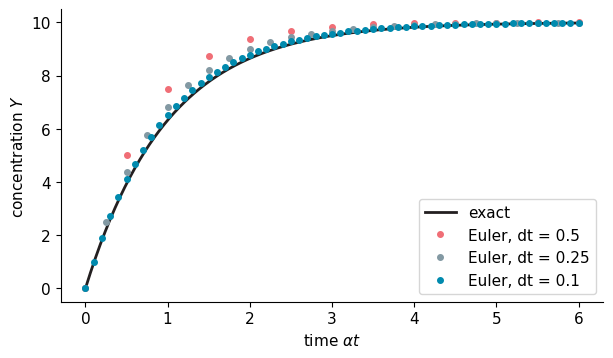

In [4]:
beta, alpha, Y0, t_end = 10.0, 1.0, 0.0, 6.0
t_fine = np.linspace(0, t_end, 400)

plt.figure(figsize=(7, 3.8))
plt.plot(t_fine, Y_exact(t_fine, beta, alpha, Y0), color=INK, lw=2, label="exact")
for dt, col in [(0.5, CORAL), (0.25, GREY), (0.1, BLUE)]:
    times, values = Y_euler(beta, alpha, Y0, dt, t_end)
    error = np.max(np.abs(values - Y_exact(times, beta, alpha, Y0)))
    plt.plot(times, values, "o", color=col, ms=4, label=f"Euler, dt = {dt}")
    print(f"dt = {dt:4}: largest error = {error:.3f}  (in the units of Y)")
plt.xlabel(r"time $\alpha t$"); plt.ylabel("concentration $Y$"); plt.legend(); plt.show()

**🔮 Try it:** use `dt = 1.5` and then `dt = 2.5`. What happens, and why can a step be "too large"?

---
## 3. A stochastic simulation

> ### A different symbol, because it is a different quantity
>
> So far $Y$ has been a **concentration**: it obeys a differential equation and takes values like
> $9.7$ without embarrassment. The simulation we are about to write cannot do that. It adds and
> removes molecules **one at a time**, so what it follows is an integer, and an integer deserves
> its own symbol:
>
> | symbol | what it is | kind of number |
> |---|---|---|
> | $N$ | the number of molecules of our protein **in one cell** | an integer |
> | $Y$ | its **concentration** | a real number |
>
> They are related by the volume $V$ of the cell:
>
> $$Y = \frac{N}{V} , \qquad\text{equivalently}\qquad N = Y V .$$
>
> The rates have to be converted along with them. Write $\beta_Y$ for the production rate measured
> in concentration per unit time, and $\beta_N$ for the same process counted in molecules per unit
> time:
>
> $$\beta_N = \beta_Y\, V , \qquad \alpha \ \text{is the same in both.}$$
>
> $\alpha$ survives untouched because removal is a **first-order** process --- each molecule
> leaves on its own, so the rate per molecule does not care how big the cell is.
>
> **The equation keeps its shape.** Dividing
> $d\langle N\rangle/dt = \beta_N - \alpha \langle N\rangle$ by $V$ returns
> $dY/dt = \beta_Y - \alpha Y$, the equation of Section 1. Read that carefully, because it settles
> a question the next figure would otherwise raise: **the differential equation describes the mean
> of $N$**, and a mean of integers is not an integer. That is how $Y$ can be $9.7$ while every
> individual cell holds a whole number.
>
> **In this section we count molecules**, with $\beta_N = 10$ molecules per unit
> time and $\alpha = 1$ per unit time, so the mean settles at $\langle N \rangle = 10$ molecules
> per cell. From Section 4 on, where transcription factors bind to DNA, concentrations are the
> natural choice and we go back to them.
>
> **One warning, for later.** The conversion was painless because our two reactions are of order
> zero (production ignores $N$) and order one (each molecule is removed by itself). As soon as
> **two molecules must meet**, the rate constant itself depends on the volume: the binding rate
> $k_{\mathrm{on}} X D$ of the pre-read becomes
> $k_{\mathrm{on}}^{\text{(counts)}} = k_{\mathrm{on}}/V$ in molecule numbers, because two
> molecules in a large cell meet less often than the same two in a small one. Whenever a model
> mixes reaction orders, decide at the start which you are counting and convert every rate.

With few molecules, $N$ changes by random events. We keep the **same two rates** and use these
rules, in a short time step $dt$:

- one molecule is produced with probability $\beta_N\,dt$;
- one of the $N$ molecules is removed with probability $\alpha N\,dt$ (each molecule with
  probability $\alpha\,dt$);
- otherwise nothing happens.

Each step, the computer draws one random number $u$ between 0 and 1 and decides.

> **This is not quite what happens in a cell.** Real events do not wait for the start of a time
> step: they happen at any instant. What we do here is chop time into slices small enough that at
> most one event fits in a slice, which is an approximation, and a good one only while
> $\beta_N\,dt$ and $\alpha N\,dt$ stay well below 1. There **is** an exact method, which draws
> the time of the next event directly instead of stepping through empty slices: it is called the
> **Gillespie algorithm**, and we have not seen it yet. So when you read the figures below, the
> jaggedness is real biology; the grid of equally spaced times is ours.

In [5]:
def simulate_cell(beta, alpha, t_end, dt, rng, N0=0):
    '''One cell: returns the list of molecule NUMBERS at times 0, dt, 2dt, ...'''
    N = N0
    history = [N]
    for step in range(int(round(t_end / dt))):
        u = rng.random()
        if u < beta * dt:                          # production
            N = N + 1
        elif u < beta * dt + alpha * N * dt:       # removal
            N = N - 1
        history.append(N)
    return history

beta, alpha = 10.0, 1.0      # beta in molecules per unit time; mean settles at beta/alpha = 10
dt, t_end = 0.01, 8.0        # beta*dt + alpha*N*dt stays well below 1
times = np.arange(int(round(t_end / dt)) + 1) * dt

### 3a. Three cells, then two thousand

**PREDICT:** three cells, all starting empty. Will they follow the smooth curve? Will they be
identical? And if we run two thousand of them and look at where each one is at the end, what shape
will that histogram have?

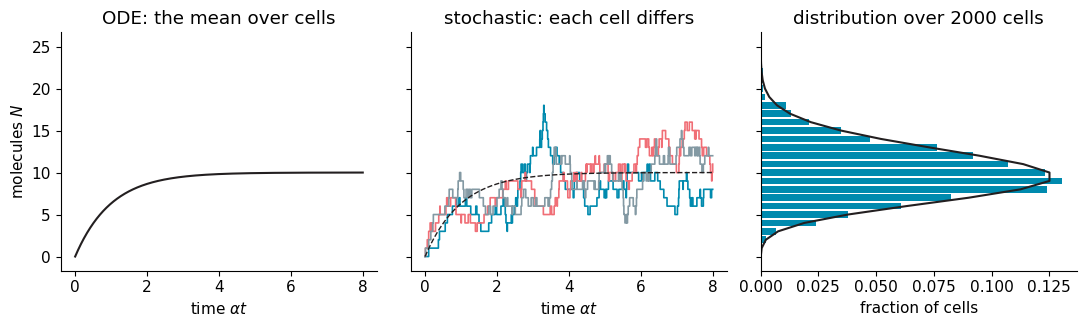

at the end: mean 9.97, variance 10.06, Fano factor 1.01
fraction of cells holding exactly 10: 0.123


In [6]:
rng = np.random.default_rng(1)
three = [simulate_cell(beta, alpha, t_end, dt, rng) for _ in range(3)]
all_cells = np.array([simulate_cell(beta, alpha, t_end, dt, rng) for _ in range(2000)])
final = all_cells[:, -1]

N_mean = beta / alpha * (1 - np.exp(-alpha * times))      # the ODE, read as the mean of N
k = np.arange(0, 26)
poisson = np.array([math.exp(-beta) * beta ** int(i) / math.factorial(int(i)) for i in k])
fraction = np.array([np.mean(final == i) for i in k])

fig, (p1, p2, p3) = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
p1.plot(times, N_mean, color=INK)
p1.set(title="ODE: the mean over cells", xlabel=r"time $\alpha t$", ylabel="molecules $N$")
for traj, col in zip(three, [BLUE, CORAL, GREY]):
    p2.step(times, traj, where="post", color=col, lw=1.2)
p2.plot(times, N_mean, color=INK, lw=1, ls="--")
p2.set(title="stochastic: each cell differs", xlabel=r"time $\alpha t$")
p3.barh(k, fraction, height=0.8, color=BLUE)
p3.plot(poisson, k, color=INK, lw=1.5)
p3.set(title="distribution over 2000 cells", xlabel="fraction of cells")
plt.tight_layout(); plt.show()

print(f"at the end: mean {final.mean():.2f}, variance {final.var():.2f}, "
      f"Fano factor {final.var() / final.mean():.2f}")
print(f"fraction of cells holding exactly 10: {np.mean(final == 10):.3f}")

The three panels share the same vertical axis, so read them as one picture of the same gene.

**Left**, the ODE: one smooth curve, the answer you get with pen and paper. **Middle**, three
cells: each one jumps between whole numbers, none of them follows the curve, and yet they all
wander around it. **Right**, turn the picture on its side and count where two thousand cells
ended up --- and the scatter that looked like a nuisance in the middle panel turns out to have a
definite shape.

So the ODE is not a poor description of a cell. It is an exact description of the **average** over
cells, and the price of that convenience is that it cannot see the panel on the right.

The black curve drawn over the histogram is a **Poisson distribution** with mean $\beta/\alpha$.
It was not fitted to the data --- it comes from a formula. That deserves an explanation.

### 3b. Why Poisson?

At steady state the cell is not standing still: it keeps making and destroying molecules. What has
settled down is not the number but the **distribution**. Write $p(N)$ for the fraction of time the
cell holds exactly $N$ molecules. (We keep the letter $N$ for a count; the $n$ of Section 4 will
be something else entirely, a Hill coefficient.)

For that distribution to be steady, the traffic between two neighbouring values must balance. As
often as the cell steps up from $N-1$ to $N$, it must step back down from $N$ to $N-1$:

- **up**, from $N-1$: production happens at rate $\beta$, and the cell sits at $N-1$ a fraction
  $p(N-1)$ of the time;
- **down**, from $N$: removal happens at rate $\alpha N$, because each of the $N$ molecules
  present can be the one to go, and the cell sits at $N$ a fraction $p(N)$ of the time.

Balancing the two,

$$\beta\, p(N-1) = \alpha\, N\, p(N) \qquad\Longrightarrow\qquad p(N) = \frac{\beta/\alpha}{N}\, p(N-1) .$$

Now climb from the bottom. Writing $\lambda = \beta/\alpha$:

$$p(1) = \lambda\, p(0), \qquad p(2) = \frac{\lambda^2}{2}\, p(0), \qquad \dots \qquad
p(N) = \frac{\lambda^N}{N!}\, p(0) .$$

Finally $p(0)$ is fixed by the requirement that the probabilities add up to 1. Since
$\sum_N \lambda^N/N! = e^{\lambda}$, we need $p(0) = e^{-\lambda}$, and

$$\boxed{\;p(N) = e^{-\lambda}\,\frac{\lambda^N}{N!}, \qquad \lambda = \frac{\beta}{\alpha}\;}$$

which is the **Poisson distribution**. Nothing was assumed about it: it is forced by a constant
production rate working against a removal proportional to how much is there.

Two consequences follow from the formula, and we can check both:

- its variance equals its mean, so the **Fano factor** $\sigma^2/\langle N\rangle$ is **1**;
- its relative noise is $\sigma/\langle N\rangle = 1/\sqrt{\lambda}$ --- **the fewer molecules, the
  noisier the cell**, and the same $1/\sqrt{\text{number}}$ that appeared at division in
  Lecture 1.

**PREDICT:** for steady states of 5, 20 and 50 molecules, what are the Fano factor and the
relative noise?

In [7]:
rng = np.random.default_rng(3)
n_cells = 500
for beta_test in [5.0, 20.0, 50.0]:
    dt_test = 0.1 / beta_test                    # keeps beta*dt + alpha*Y*dt small
    final_test = np.array([simulate_cell(beta_test, alpha, t_end, dt_test, rng)[-1]
                           for i in range(n_cells)])
    print(f"beta/alpha = {beta_test:4.0f}: mean {final_test.mean():5.1f}, "
          f"Fano {final_test.var() / final_test.mean():.2f}, "
          f"relative noise {final_test.std() / final_test.mean():.3f}  "
          f"(1/sqrt(mean) = {1 / math.sqrt(beta_test / alpha):.3f})")

beta/alpha =    5: mean   5.2, Fano 0.94, relative noise 0.427  (1/sqrt(mean) = 0.447)


beta/alpha =   20: mean  19.7, Fano 0.93, relative noise 0.217  (1/sqrt(mean) = 0.224)


beta/alpha =   50: mean  49.8, Fano 1.05, relative noise 0.145  (1/sqrt(mean) = 0.141)


The Fano factor stays near 1 whatever the steady state, and the relative noise follows
$1/\sqrt{\lambda}$: a gene held at 5 copies is about three times noisier, in relative terms, than
one held at 50.

---
## 4. Gene regulation: the input function

Until now the production rate $\beta$ has been a fixed number. That describes a gene that is
simply on. Most genes are not: their production rate depends on the concentration of a
**transcription factor** $X$, a protein that binds the promoter and changes how often the gene is
read. The equation becomes

$$\frac{dY}{dt} = f(X) - \alpha Y ,$$

and the question is what $f$ looks like.

**Why one function can stand in for all of that.** $X$ binds and unbinds the promoter thousands of
times a second, so the promoter flickers between states far faster than the protein concentration
can change, which takes hours. On the timescale we care about only the *average* promoter activity
at a given level of $X$ matters, and that average is what $f(X)$ is. It is the same move as the
steady state in Lecture 1: when one process is much faster than another, replace it by the value
it has already settled to.

For a **repressor** --- $X$ binding shuts the gene down --- a good description of many promoters is
the decreasing **Hill function**

$$f(X) = \beta\,\frac{K^n}{K^n + X^n} .$$

Two parameters, each with one job:

- $K$, the **repression coefficient**. Put $X = K$ into the formula and you get $f = \beta/2$: $K$
  is the concentration at which the promoter runs at half speed. It has units of concentration.
- $n$, the **Hill coefficient**, which sets how sharp the switch is. It is a pure number.

You met the activating version in the pre-read; this is the same shape turned over.

**PREDICT:** the figure below draws the curve for $n = 1, 2, 4$ and $10$, all with the same $K$.
Which one falls most steeply? And do they all pass through the same point?

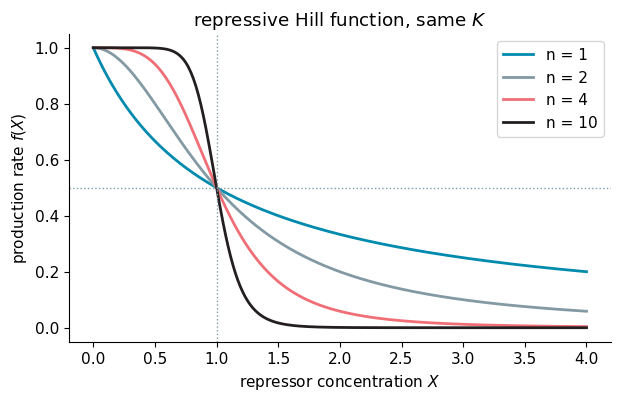

every curve passes through f(K) = beta/2:
  n =  1:  f(K) = 0.500
  n =  2:  f(K) = 0.500
  n =  4:  f(K) = 0.500
  n = 10:  f(K) = 0.500


In [8]:
def hill_repressor(X, beta, K, n):
    '''Production rate of a gene repressed by X.'''
    return beta * K**n / (K**n + X**n)

beta_max, K = 1.0, 1.0
X_axis = np.linspace(0, 4, 400)

plt.figure(figsize=(7, 4))
for n, col in [(1, BLUE), (2, GREY), (4, CORAL), (10, INK)]:
    plt.plot(X_axis, hill_repressor(X_axis, beta_max, K, n), color=col, lw=2, label=f"n = {n}")
plt.axvline(K, color=GREY, ls=":", lw=1)
plt.axhline(beta_max / 2, color=GREY, ls=":", lw=1)
plt.xlabel("repressor concentration $X$"); plt.ylabel("production rate $f(X)$")
plt.title("repressive Hill function, same $K$")
plt.legend(); plt.show()

print("every curve passes through f(K) = beta/2:")
for n in [1, 2, 4, 10]:
    print(f"  n = {n:2d}:  f(K) = {hill_repressor(K, beta_max, K, n):.3f}")

All four cross at $X = K$, where $f = \beta/2$. That is what $K$ **means**, and it does not depend
on $n$. What $n$ changes is the sharpness: at $n = 1$ the gene dims gradually across a wide range
of $X$, while at $n = 10$ it is nearly a switch --- full on below $K$, off above it.

That last observation earns a name. Taking $n$ large gives the **logic approximation**: production
is $\beta$ while $X < K$, and $0$ once $X > K$. We use it in Section 6 to get an answer on
the board in two lines.

---
## 5. Network motifs

Until now we looked at one gene at a time. In a cell, transcription factors are themselves made by
genes that other transcription factors regulate, so the regulatory links form a **network**: each
gene is a node, and an arrow from $X$ to $Y$ means that the protein made by $X$ regulates gene $Y$.

Alon's question about such a network is: **which patterns occur in it more often than they would
by chance?** A raw count does not answer it. Forty copies of a pattern may be a lot or very few,
depending on how many copies a network with the same number of genes and arrows, wired at random,
would contain. So every count gets compared with a randomized network --- the same move as
asking, in the coin experiments, whether a number of heads is surprising for a fair coin.

The simplest pattern there is: an arrow from a gene **to itself**, a gene that regulates its own
production.

### 5a. The real network

> **What is in `data/coliInterFullVec.txt`**
>
> The transcription network of *Escherichia coli*, from Uri Alon's laboratory: which genes
> regulate which. It is a plain text file, **one line per regulatory arrow**, with three numbers
> separated by spaces:
>
> | column | meaning |
> |---|---|
> | 1 | the regulating gene (the transcription factor), as a number |
> | 2 | the gene it regulates |
> | 3 | the kind of regulation: **1** = activator, **2** = repressor, **3** = both |
>
> So the line `3 4 2` reads "gene 3 represses gene 4". Genes are identified by number rather than
> by name; a separate file in the original database holds the names, and we do not need them
> today. There are 578 lines.

**A question before any code.** You are about to count how many genes regulate *themselves*. You
could reach for a network library --- and we will, in a moment, but only to draw the picture.
**Without knowing a single library function, how would you get that number out of this file?**

Think about what a self-regulating gene looks like *as a line of text*.

In [9]:
arrows = []
with open("data/coliInterFullVec.txt") as f:
    for line in f:
        parts = line.split()
        if len(parts) == 3:
            arrows.append((int(parts[0]), int(parts[1]), int(parts[2])))

# a gene regulates itself when the first two columns are the same number
self_arrows = [(a, b, mode) for a, b, mode in arrows if a == b]

nodes = {a for a, b, mode in arrows} | {b for a, b, mode in arrows}
N_nodes, A_arrows = len(nodes), len(arrows)

print(f"{A_arrows} arrows between {N_nodes} genes")
print(f"self-arrows: {len(self_arrows)}")
print(f"   repressing themselves : {sum(1 for a, b, m in self_arrows if m == 2)}")
print(f"   activating themselves : {sum(1 for a, b, m in self_arrows if m == 1)}")
print(f"   both                  : {sum(1 for a, b, m in self_arrows if m == 3)}")

578 arrows between 423 genes
self-arrows: 59
   repressing themselves : 42
   activating themselves : 14
   both                  : 3


That is the whole answer: a self-regulating gene is a line whose first two numbers are equal, so
the count is one `if` inside the loop that reads the file. No library was needed, and it is worth
noticing before we import one --- a network is a list of pairs, and most questions about it are
questions about that list.

The set of genes is built the same way: collect every number that appears in either column, and
count how many different ones there are.

**PREDICT, before the next cell:** scatter the same number of arrows at random among the same
genes. How many would land back on their own gene?

In [10]:
expected = A_arrows / N_nodes                 # each arrow returns to its origin with chance 1/N
spread = math.sqrt(expected)                  # A tries, each unlikely: spread = sqrt(mean)

print(f"random network : {expected:.2f} +- {spread:.2f} self-arrows")
print(f"E. coli        : {len(self_arrows)}")
print(f"distance       : {(len(self_arrows) - expected) / spread:.0f} standard deviations")

random network : 1.37 +- 1.17 self-arrows
E. coli        : 59
distance       : 49 standard deviations


Roughly one expected by accident, and we count **59**: about fifty standard deviations away. A
pattern that appears far more often in the real network than in the randomized one is called a
**network motif**, and self-regulation is the first one we meet. Note which kind dominates: most
of those genes **repress** themselves.

> **A note on the numbers.** Alon's book reports 424 genes, 519 arrows and 40 self-arrows, and you
> have just counted 423, 578 and 59. The file is a later version of the same database: arrows have
> been added as they were discovered. The conclusion is not delicate --- it survives the update
> easily, and in fact gets stronger --- but it is worth seeing that a published number and the
> current data need not agree, and that you should say which you used.

### 5b. Drawing it

Counting needed no library. Drawing does, because deciding *where to put 423 dots on a page* is a
real problem in itself. `networkx` is the usual Python choice, and we use four of its functions:

- `nx.DiGraph()` makes an empty **directed** graph, and `add_edges_from` fills it with our pairs;
- `nx.spring_layout` invents the positions. It pretends every arrow is a spring pulling two genes
  together and every pair of genes pushes apart, then lets that settle. The result has no units
  and no meaning of its own --- only *who sits near whom* is informative, and `seed=4` just fixes
  which of the many equally good arrangements we get;
- `draw_networkx_edges` and `draw_networkx_nodes` draw the pieces, which lets us give the
  self-arrows and the self-regulating genes their own colour.

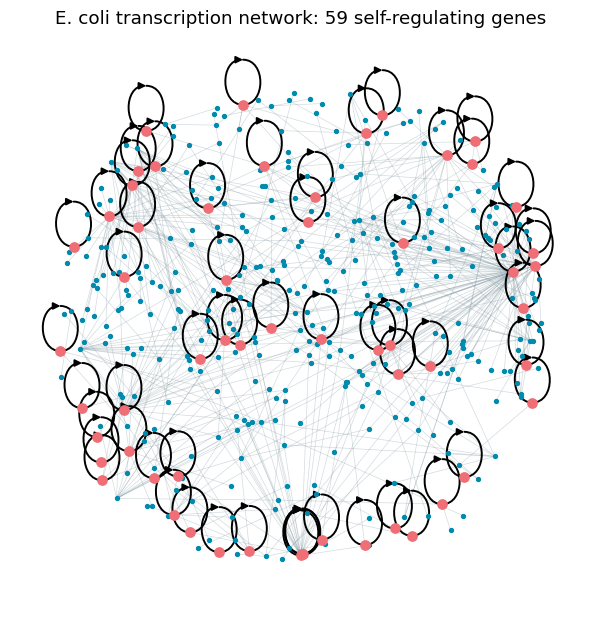

In [11]:
import networkx as nx

graph = nx.DiGraph()
graph.add_edges_from([(a, b) for a, b, mode in arrows])

loops = [(a, b) for a, b in graph.edges() if a == b]           # the self-arrows
rest = [(a, b) for a, b in graph.edges() if a != b]            # everything else
loop_genes = [a for a, b in loops]

plt.figure(figsize=(7.5, 7.5))
positions = nx.spring_layout(graph, seed=4, k=0.25)
nx.draw_networkx_edges(graph, positions, edgelist=rest, edge_color=GREY,
                       alpha=0.35, arrows=False, width=0.5)
nx.draw_networkx_edges(graph, positions, edgelist=loops, edge_color="black",
                       arrows=True, width=1.4)
nx.draw_networkx_nodes(graph, positions, node_size=8, node_color=BLUE)
nx.draw_networkx_nodes(graph, positions, nodelist=loop_genes, node_size=45, node_color=CORAL)
plt.title(f"E. coli transcription network: {len(loops)} self-regulating genes")
plt.axis("off"); plt.show()

Each black circle is a gene regulating itself, and the red dots mark those genes among the 423.
They are not clustered in one corner: self-regulation is spread all over the network, which is
part of why it looks like a repeated design rather than a quirk of one gene family.

Finding a motif is only half the job. The question that follows is **what is it for?** A pattern
that keeps being selected is presumably doing something useful, and we can ask what by comparing
the circuit against the simple gene of Lecture 1.

---
## 6. What is it for? Self-repression is fast

### On the board

Take a gene that represses itself. Using the logic approximation from Section 4, while $X$ is
still below $K$ the promoter is fully active:

$$\frac{dX}{dt} = \beta - \alpha X \qquad \text{while } X < K ,$$

and at early times, when $X$ is still small, removal is negligible ($\alpha X \ll \beta$):

$$X(t) \simeq \beta t .$$

The protein piles up in a straight line. Then production shuts off at $X = K$, so the circuit locks
at

$$X_{\text{st}} = K ,$$

and the time to reach half of that follows from $\beta\,T_{1/2} = K/2$:

$$\boxed{\;T_{1/2}^{\text{NAR}} = \frac{K}{2\beta}\;}$$

**Now compare it fairly.** A comparison only means something if the two circuits do the same job,
so give the simple gene the same removal rate $\alpha$ and the same steady state. The simple gene
of Lecture 1 has $X_{\text{st}} = \beta_{\text{simple}}/\alpha$ and $T_{1/2} = \ln 2/\alpha$ ---
and notice what that means: **its response time cannot be changed without moving its steady
state**, because the single number $\alpha$ fixes both.

The self-repressing gene is not stuck with that. It can use a strong promoter for a fast start and
then stop itself at $K$. Where it ends up and how fast it gets there are set by two different
parameters.

**PREDICT:** both circuits below reach the same steady state, with the same $\alpha$. Which gets
halfway first, and by roughly how much?

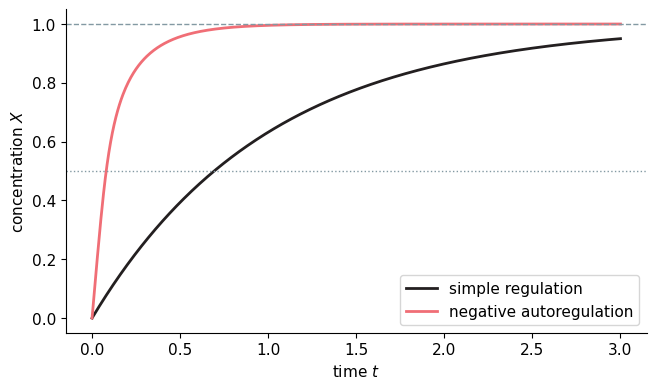

K chosen so that both settle at X_st = 1.0:  K = 0.6389
simple regulation : T_1/2 = 0.6931   (ln2/alpha = 0.6931)
autoregulation    : T_1/2 = 0.0803
speed-up          : 8.6 times faster
board estimate K/(2*beta) = 0.0456


In [12]:
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

alpha_r, Xst = 1.0, 1.0                  # same removal rate and same steady state for both
beta_simple = alpha_r * Xst              # simple regulation: Xst = beta/alpha
beta_nar, n_hill = 7.0, 4                # NAR: much stronger promoter, held back by repression

K_nar = brentq(lambda K: hill_repressor(Xst, beta_nar, K, n_hill) - alpha_r * Xst, 1e-6, 100)

def half_time(rhs):
    sol = solve_ivp(rhs, [0, 10], [0.0], dense_output=True, rtol=1e-10, atol=1e-12)
    return brentq(lambda t: sol.sol(t)[0] - Xst / 2, 1e-9, 10), sol

T_simple, sol_simple = half_time(lambda t, y: [beta_simple - alpha_r * y[0]])
T_nar, sol_nar = half_time(
    lambda t, y: [hill_repressor(y[0], beta_nar, K_nar, n_hill) - alpha_r * y[0]])

t_axis = np.linspace(0, 3, 600)
plt.figure(figsize=(7.5, 4.2))
plt.plot(t_axis, sol_simple.sol(t_axis)[0], color=INK, lw=2, label="simple regulation")
plt.plot(t_axis, sol_nar.sol(t_axis)[0], color=CORAL, lw=2, label="negative autoregulation")
plt.axhline(Xst, color=GREY, ls="--", lw=1)
plt.axhline(Xst / 2, color=GREY, ls=":", lw=1)
plt.xlabel("time $t$"); plt.ylabel("concentration $X$"); plt.legend(); plt.show()

print(f"K chosen so that both settle at X_st = {Xst}:  K = {K_nar:.4f}")
print(f"simple regulation : T_1/2 = {T_simple:.4f}   (ln2/alpha = {math.log(2) / alpha_r:.4f})")
print(f"autoregulation    : T_1/2 = {T_nar:.4f}")
print(f"speed-up          : {T_simple / T_nar:.1f} times faster")
print(f"board estimate K/(2*beta) = {K_nar / (2 * beta_nar):.4f}")

Same destination, same removal rate, and the self-repressing circuit arrives **8.6 times
sooner**. Nothing came free: the price is a promoter seven times stronger, which on its own would
have overshot the target badly. Repression is what turns that strength into speed instead of into
too much protein.

The board estimate $K/2\beta$ lands about a factor of two below the measured value, which is what
we should expect: the logic approximation replaces the Hill curve by a sharp switch, and $n = 4$ is
not that sharp. It gets the size and the scaling right, which is what it was for.

This speed-up is not only a calculation. It was measured, by following a real autoregulated gene
in *E. coli* with time-resolved expression measurements (Rosenfeld, Elowitz and Alon, 2002).

---
## 7. What else is it for? Robustness

Cells of the same strain, grown side by side, do not all have the same production rate $\beta$ for
a given gene. It differs from cell to cell by **tens of percent**, because cells differ in their
metabolic capacity and in their regulatory machinery, and a cell keeps its difference for about a
generation (Alon, Section 2.5).

This is a **second source** of differences between cells, and it is not the one of Section 3.
There, every cell had the same $\beta$ and the cells differed only because single production and
removal events happen at random. Here the cells differ in $\beta$ itself.

The question is how much of a difference in $\beta$ reaches the steady state. Measure it with the
**sensitivity**, the relative change of $X_{\text{st}}$ divided by the relative change of $\beta$
that caused it:

$$S = \frac{\Delta X_{\text{st}}/X_{\text{st}}}{\Delta\beta/\beta}
    = \frac{\beta}{X_{\text{st}}}\,\frac{dX_{\text{st}}}{d\beta} .$$

$S = 1$ means that a 10% change in $\beta$ gives a 10% change in the protein; $S = 0$ means the
protein does not notice.

### On the board

- **Simple regulation.** $X_{\text{st}} = \beta/\alpha$, so $S = 1$: every difference in $\beta$
  is passed on in full.
- **Self-repression, logic approximation.** $X_{\text{st}} = K$, which does not contain $\beta$ at
  all, so $S = 0$.
- **Self-repression, Hill function.** At steady state production balances removal,
  $\beta K^n/(K^n + X^n) = \alpha X$. Take the logarithm of both sides and differentiate with
  respect to $\ln\beta$. The result is

$$\boxed{\;S = \frac{1}{1 + n\,\theta}\;}, \qquad \theta = \frac{X_{\text{st}}^n}{K^n + X_{\text{st}}^n} ,$$

where $\theta$ is the fraction of time the promoter is occupied by the repressor --- the quantity
you computed in Step 4 of the pre-read. A weakly repressed gene ($\theta \to 0$) behaves like
simple regulation, $S \to 1$. A strongly repressed one ($\theta \to 1$) has $S \to 1/(n+1)$:
for $n = 4$, a 10% change in $\beta$ moves the protein by about 2%.

$\beta$ and $\alpha$ enter the steady-state condition only through $\beta/\alpha$, so the same $S$
holds, with a minus sign, for changes in the removal rate --- for instance when the cells grow
faster and dilute their proteins faster.

**PREDICT:** take the two circuits of Section 6 and give 2000 cells a production rate that
differs from cell to cell by 20%. How much do the steady states differ, for each circuit?

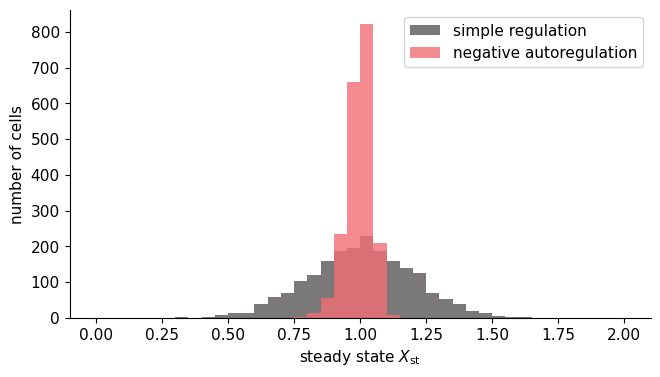

spread of beta between cells : 0.195  (relative)
spread of X_st, simple       : 0.195
spread of X_st, autoregulated: 0.046
occupancy theta = 0.857,  S = 1/(1 + n*theta) = 0.226


In [13]:
rng = np.random.default_rng(5)
factor = rng.normal(1.0, 0.2, 2000)          # each cell's beta, relative to the nominal value

def steady_state_nar(beta):
    '''Steady state of dX/dt = f(X) - alpha*X with the repressive Hill function of Section 6.'''
    return brentq(lambda X: hill_repressor(X, beta, K_nar, n_hill) - alpha_r * X, 0, beta / alpha_r)

X_simple = beta_simple * factor / alpha_r
X_nar = np.array([steady_state_nar(beta_nar * f) for f in factor])

bins = np.linspace(0, 2, 41)
plt.figure(figsize=(7.5, 4))
plt.hist(X_simple, bins=bins, color=INK, alpha=0.6, label="simple regulation")
plt.hist(X_nar, bins=bins, color=CORAL, alpha=0.8, label="negative autoregulation")
plt.xlabel(r"steady state $X_{\mathrm{st}}$"); plt.ylabel("number of cells"); plt.legend(); plt.show()

theta = Xst**n_hill / (K_nar**n_hill + Xst**n_hill)
print(f"spread of beta between cells : {factor.std() / factor.mean():.3f}  (relative)")
print(f"spread of X_st, simple       : {X_simple.std() / X_simple.mean():.3f}")
print(f"spread of X_st, autoregulated: {X_nar.std() / X_nar.mean():.3f}")
print(f"occupancy theta = {theta:.3f},  S = 1/(1 + n*theta) = {1 / (1 + n_hill * theta):.3f}")

The simple gene passes the 20% spread in $\beta$ on to its protein unchanged. The self-repressing
gene reduces it to about 5%, roughly a factor $1/S$. The match with $S$ is not exact, because $S$
describes small changes and 20% is not small.

This was measured in single cells on engineered circuits, with and without self-repression
(Becskei and Serrano, 2000), and the robustness to the growth rate was measured later (Klumpp,
Zhang and Hwa, 2009). Both are cited in Alon, Section 2.5.

> **Where this goes next.**
> - **Robustness** --- a property that stays put while the parameters underneath it change --- is
>   one of the recurring ideas of systems biology, and Alon devotes the second part of his book
>   to it.
> - **Positive** autoregulation does roughly the opposite: it slows responses down and can
>   amplify differences between cells (Alon, Chapter 5).
> - **An open question for Lecture 3.** This section dealt with cells that differ in $\beta$. Does
>   self-repression also reduce the noise of Section 3, the one that comes from single events
>   happening at random? The differential equation cannot answer that: it only describes the
>   mean. A stochastic simulation can.

---
### What we did

| method | what it gives | limits |
|---|---|---|
| analytical | the exact average curve | only for simple equations |
| numerical (Euler) | any equation, approximately | the step must be small enough |
| stochastic simulation | single cells, and the distribution over cells | needs many runs; slower --- and the fixed-$dt$ version above is itself an approximation, unlike the Gillespie algorithm we have not yet seen |

And then three steps beyond a single unregulated gene:

- the **input function** $f(X)$, in the Hill form $\beta K^n/(K^n + X^n)$: $K$ says where the
  gene runs at half activity, $n$ says how sharp the switch is;
- the first **network motif**: a self-arrow appears 59 times in the *E. coli* data where chance
  would put about 1;
- what it is good for: negative autoregulation **separates how fast a gene responds from where it
  settles**, which simple regulation cannot do, and it makes the steady state **less sensitive**
  to differences in production rate between cells.